 Install Libraries & Import


In [1]:
# Install required libraries
!pip install wordcloud textblob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


 Load the Dataset

In [5]:
# Load training dataset (already uploaded)
train_df = pd.read_csv('twitter_training (1).csv',   # ← note the renamed file
                        header=None,
                        names=['TweetID', 'Entity', 'Sentiment', 'Tweet'])

# For validation — either upload it, or split from training:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['Sentiment'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("\nFirst 5 rows:")
train_df.head()

Training shape: (59745, 4)
Validation shape: (14937, 4)

First 5 rows:


,TweetID,Entity,Sentiment,Tweet
0,126,Amazon,Neutral,"This dangerous ""party drug"" was everywhere - e..."
1,8557,NBA2K,Negative,@ NBA2K crappy ass fucking update made this ga...
2,13004,Xbox(Xseries),Positive,"At the same time, despite the fact that there ..."
3,12560,WorldOfCraft,Positive,Idk... i cant concentrate enough to draw good ...
4,7200,johnson&johnson,Negative,WE PROTECT JOHNSON & JOHNSON AND PFIZER FOR A ...


Explore & Clean Data

In [6]:
# Basic Info
print("=== DATASET INFO ===")
print(train_df.info())
print("\n=== MISSING VALUES ===")
print(train_df.isnull().sum())
print("\n=== SENTIMENT CATEGORIES ===")
print(train_df['Sentiment'].value_counts())
print("\n=== TOP ENTITIES (Brands/Topics) ===")
print(train_df['Entity'].value_counts().head(10))

# Drop rows where Tweet is missing
train_df.dropna(subset=['Tweet'], inplace=True)
val_df.dropna(subset=['Tweet'], inplace=True)

# Convert Tweet to string
train_df['Tweet'] = train_df['Tweet'].astype(str)
val_df['Tweet'] = val_df['Tweet'].astype(str)

print("\n✅ Data cleaned!")

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59745 entries, 0 to 59744
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   TweetID    59745 non-null  int64 
 1   Entity     59745 non-null  object
 2   Sentiment  59745 non-null  object
 3   Tweet      59199 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.8+ MB
None

=== MISSING VALUES ===
TweetID        0
Entity         0
Sentiment      0
Tweet        546
dtype: int64

=== SENTIMENT CATEGORIES ===
Sentiment
Negative      18033
Positive      16666
Neutral       14654
Irrelevant    10392
Name: count, dtype: int64

=== TOP ENTITIES (Brands/Topics) ===
Entity
Microsoft                    1948
CallOfDutyBlackopsColdWar    1940
LeagueOfLegends              1934
TomClancysRainbowSix         1919
CallOfDuty                   1914
Verizon                      1914
FIFA                         1904
Dota2                        1903
NBA2K         

Text Preprocessing

In [7]:
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = text.lower()                              # Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)      # Remove URLs
    text = re.sub(r'@\w+', '', text)                # Remove @mentions
    text = re.sub(r'#', '', text)                   # Remove hashtag symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)         # Remove punctuation/numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]  # Remove stopwords
    return ' '.join(tokens)

train_df['Cleaned_Tweet'] = train_df['Tweet'].apply(clean_tweet)
val_df['Cleaned_Tweet'] = val_df['Tweet'].apply(clean_tweet)

print("Sample cleaned tweet:")
print("Original:", train_df['Tweet'].iloc[0])
print("Cleaned:", train_df['Cleaned_Tweet'].iloc[0])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Sample cleaned tweet:
Original: This dangerous "party drug" was everywhere - even on Amazon nbcnews.com / feature / nbc-ou... via @ nbcnews
Cleaned: dangerous party drug everywhere even amazon nbcnewscom feature nbcou via nbcnews


 Visualizations

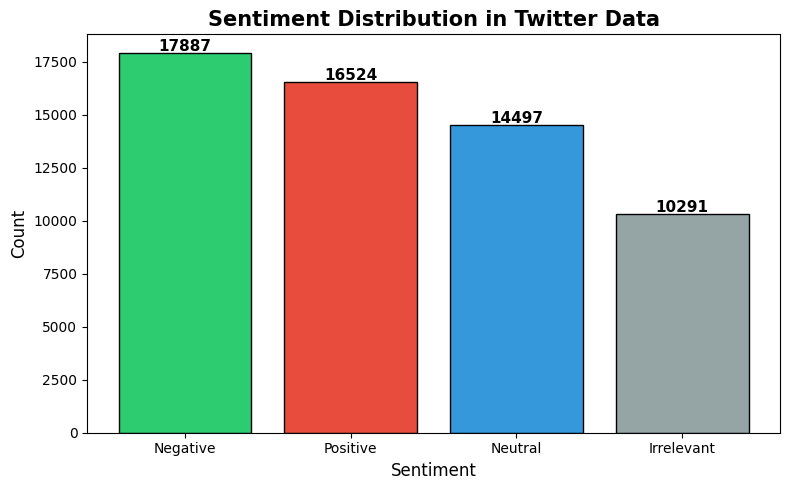

✅ Plot 1 saved!


In [8]:
# --- PLOT 1: Sentiment Distribution (Bar Chart) ---
plt.figure(figsize=(8, 5))
sentiment_counts = train_df['Sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black')
plt.title('Sentiment Distribution in Twitter Data', fontsize=15, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(count), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150)
plt.show()
print("✅ Plot 1 saved!")

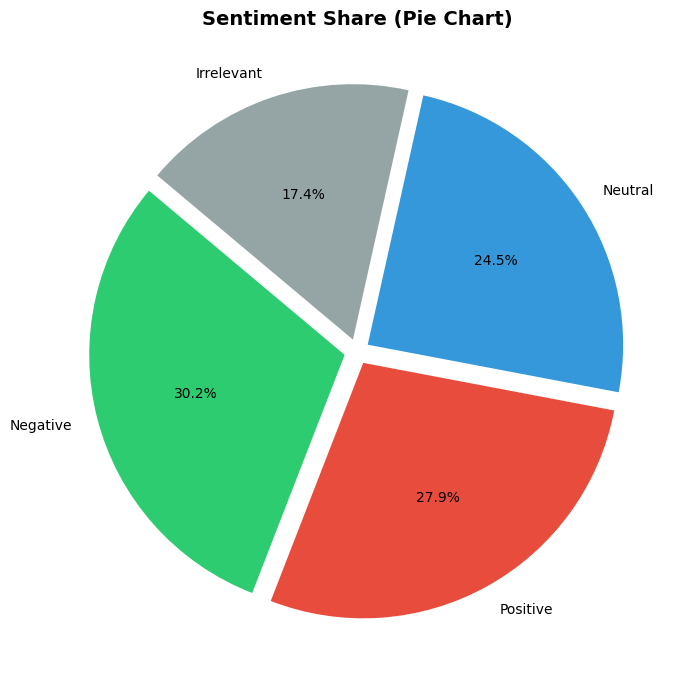

✅ Plot 2 saved!


In [9]:
# --- PLOT 2: Pie Chart ---
plt.figure(figsize=(7, 7))
plt.pie(sentiment_counts.values, labels=sentiment_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=140,
        explode=[0.05]*len(sentiment_counts))
plt.title('Sentiment Share (Pie Chart)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_pie.png', dpi=150)
plt.show()
print("✅ Plot 2 saved!")

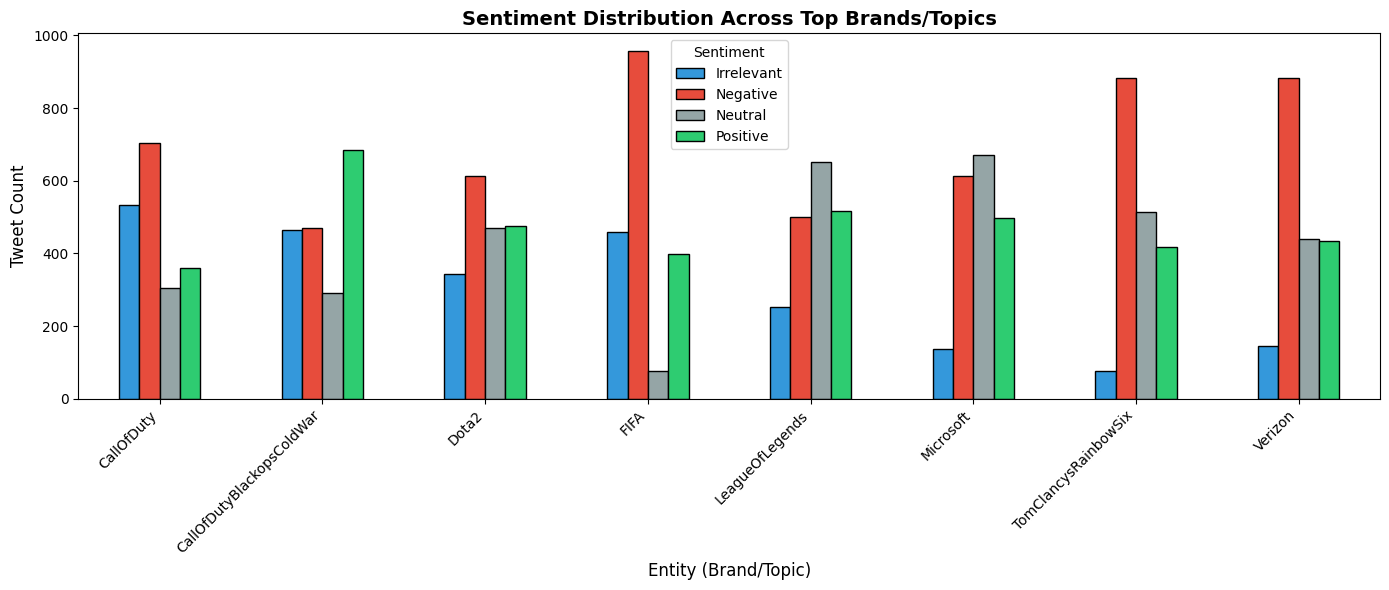

✅ Plot 3 saved!


In [10]:
# --- PLOT 3: Top Entities by Sentiment (Grouped Bar) ---
top_entities = train_df['Entity'].value_counts().head(8).index
entity_df = train_df[train_df['Entity'].isin(top_entities)]

entity_sentiment = entity_df.groupby(['Entity', 'Sentiment']).size().unstack(fill_value=0)

entity_sentiment.plot(kind='bar', figsize=(14, 6), color=['#3498db','#e74c3c','#95a5a6','#2ecc71'], edgecolor='black')
plt.title('Sentiment Distribution Across Top Brands/Topics', fontsize=14, fontweight='bold')
plt.xlabel('Entity (Brand/Topic)', fontsize=12)
plt.ylabel('Tweet Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('entity_sentiment.png', dpi=150)
plt.show()
print("✅ Plot 3 saved!")

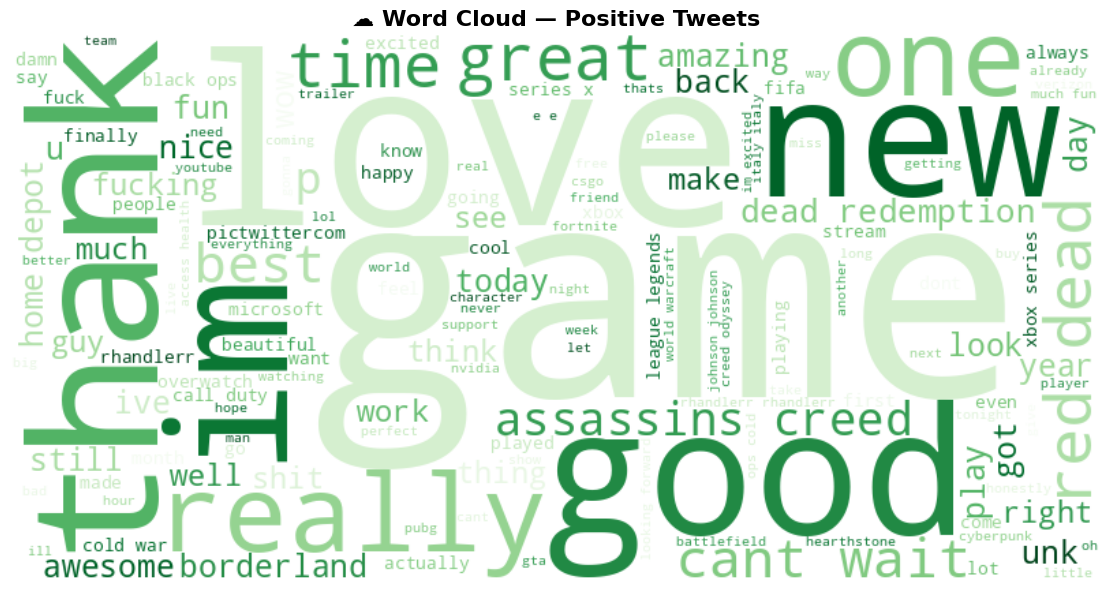

✅ Plot 4 saved!


In [11]:
# --- PLOT 4: Word Cloud for Positive Tweets ---
positive_tweets = ' '.join(train_df[train_df['Sentiment'] == 'Positive']['Cleaned_Tweet'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Greens',
                      max_words=150).generate(positive_tweets)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Word Cloud — Positive Tweets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_positive.png', dpi=150)
plt.show()
print("✅ Plot 4 saved!")

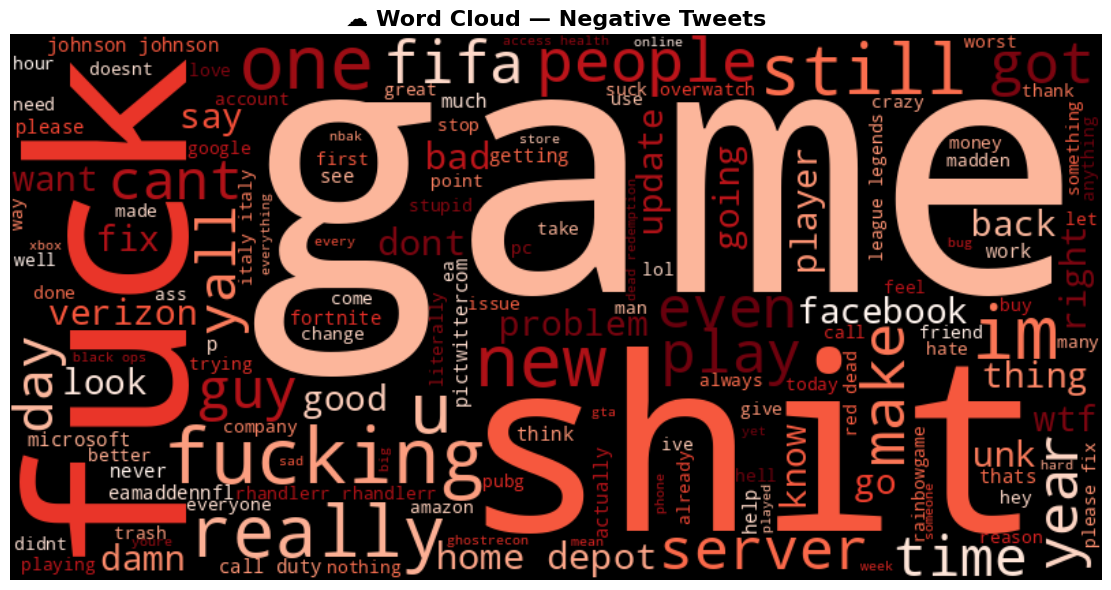

✅ Plot 5 saved!


In [12]:
# --- PLOT 5: Word Cloud for Negative Tweets ---
negative_tweets = ' '.join(train_df[train_df['Sentiment'] == 'Negative']['Cleaned_Tweet'])

wordcloud_neg = WordCloud(width=800, height=400,
                           background_color='black',
                           colormap='Reds',
                           max_words=150).generate(negative_tweets)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Word Cloud — Negative Tweets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud_negative.png', dpi=150)
plt.show()
print("✅ Plot 5 saved!")

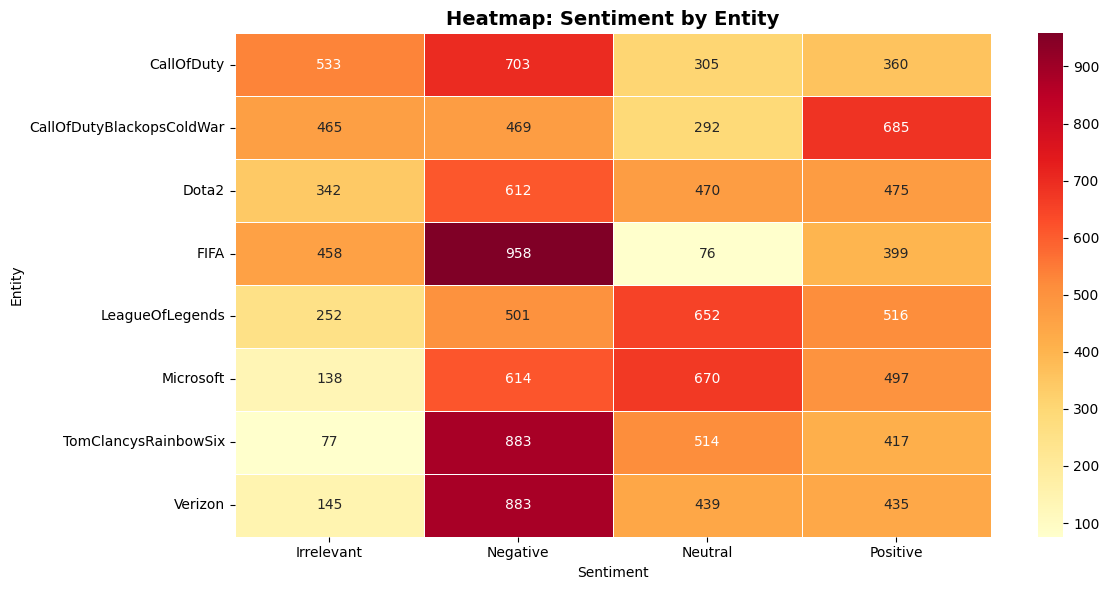

✅ Plot 6 saved!


In [13]:
# --- PLOT 6: Heatmap - Sentiment vs Entity ---
pivot = entity_df.groupby(['Entity', 'Sentiment']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Heatmap: Sentiment by Entity', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Entity')
plt.tight_layout()
plt.savefig('heatmap_sentiment.png', dpi=150)
plt.show()
print("✅ Plot 6 saved!")

Summary Insights

In [14]:
print("=" * 55)
print("      📊 SENTIMENT ANALYSIS - KEY INSIGHTS")
print("=" * 55)
total = len(train_df)
for sentiment in train_df['Sentiment'].value_counts().index:
    count = len(train_df[train_df['Sentiment'] == sentiment])
    pct = round(count / total * 100, 2)
    print(f"  {sentiment:<15}: {count:>6} tweets ({pct}%)")

print(f"\n  Total tweets analyzed : {total}")
print(f"  Total unique entities : {train_df['Entity'].nunique()}")
most_positive = entity_sentiment['Positive'].idxmax() if 'Positive' in entity_sentiment.columns else 'N/A'
most_negative = entity_sentiment['Negative'].idxmax() if 'Negative' in entity_sentiment.columns else 'N/A'
print(f"  Most positively tweeted brand : {most_positive}")
print(f"  Most negatively tweeted brand : {most_negative}")
print("=" * 55)

      📊 SENTIMENT ANALYSIS - KEY INSIGHTS
  Negative       :  17887 tweets (30.22%)
  Positive       :  16524 tweets (27.91%)
  Neutral        :  14497 tweets (24.49%)
  Irrelevant     :  10291 tweets (17.38%)

  Total tweets analyzed : 59199
  Total unique entities : 32
  Most positively tweeted brand : CallOfDutyBlackopsColdWar
  Most negatively tweeted brand : FIFA


GitHub Push

In [16]:
# In Colab terminal (click the + Code, then run these one by one):
!git config --global user.email "krisnapriyaakanagasundaram@gmail.com"
!git config --global user.name "krisnapriyaa"

!git clone https://github.com/krisnapriyaa/PRODIGY_DS_04.git
%cd PRODIGY_DS_04

# Copy your notebook here
!cp /content/*.ipynb .
!cp /content/*.png .  # Save all plots

!git add .
!git commit -m "Task 04: Twitter Sentiment Analysis - Prodigy InfoTech"
!git push origin main

Cloning into 'PRODIGY_DS_04'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'PRODIGY_DS_04'
/content
cp: cannot stat '/content/*.ipynb': No such file or directory
cp: '/content/entity_sentiment.png' and './entity_sentiment.png' are the same file
cp: '/content/heatmap_sentiment.png' and './heatmap_sentiment.png' are the same file
cp: '/content/sentiment_distribution.png' and './sentiment_distribution.png' are the same file
cp: '/content/sentiment_pie.png' and './sentiment_pie.png' are the same file
cp: '/content/wordcloud_negative.png' and './wordcloud_negative.png' are the same file
cp: '/content/wordcloud_positive.png' and './wordcloud_positive.png' are the same file
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
